# Entropy Analysis of U.S. Presidential Primaries

This notebook measures how *competitive* each presidential primary was across candidates using **Shannon entropy**. Intuitively:

- **High entropy** → votes are spread fairly evenly across several candidates (a fragmented / competitive field)
- **Low entropy** → one or two candidates dominate the vote (a clearer frontrunner, or an uncontested race)

What we do here is **within-election** analysis: for each cycle (2008, 2016, 2020), we compress each state’s primary into a single entropy value for Democrats and for Republicans, and then place those values on the actual nomination calendar.

Workflow:

1. Load cleaned, precinct-level primary results for each cycle (from `data/processed/<YEAR>/`).
2. For each state, aggregate candidate vote totals within the primary and compute **DEM entropy** and **REP entropy**.
3. Attach primary/caucus dates for each state–party pair (hard-coded from an online calendar).
4. Plot entropy vs. time to see whether fields tend to **fragment early** and **consolidate later**.

Note: **2020** is a special cycle. COVID-19 caused multiple states to postpone their primaries, and the GOP had an incumbent president, which often produces **very low / near-zero Republican entropy** (and in some states, effectively no contest). Keep that in mind when comparing across years.

**Last update: December 19, 2025**

## 0. Import Libraries & Define Data Paths

We start by importing the libraries we need (pandas/numpy for data work; matplotlib for plotting), and then define where the processed CSVs live.

This notebook expects the cleaned outputs to be organized as:

- `../../data/processed/2008/`
- `../../data/processed/2016/`
- `../../data/processed/2020/`

Each directory should contain one CSV per state, produced by the cleaning / ETL steps earlier in the project.

In [9]:
# Import necessary libraries
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [10]:
# Data path
DATA_DIR_2008 = Path("../../data/processed/2008")
DATA_DIR_2016 = Path("../../data/processed/2016")
DATA_DIR_2020 = Path("../../data/processed/2020")

At this point, the notebook has everything it needs to read the processed election files, manipulate them with pandas, and produce visualizations with matplotlib. From here on, each section follows the same pattern: load → aggregate → compute entropy → (later) align to the nomination calendar.

## 1. Load in Data

The next step is to load the **primary** data for each election cycle and compute an entropy score for each party.

Implementation-wise, each cleaned state file is already in a wide format with candidate vote columns. We:

1. Identify which columns correspond to **primary** results.
2. Split those columns into **Democratic** vs. **Republican** candidates based on the column prefix (e.g., `primary_dem_...` vs. `primary_rep_...`).
3. Sum votes across precincts to get a state-level candidate vote vector.
4. Compute Shannon entropy from that vote vector.

The output of each cycle is a compact table: one row per state, with `entropy_dem` and `entropy_rep`.

### 1.1. 2008 Presidential Election

For 2008, we focus on a subset of states that have relatively complete processed data (primary present, and missingness not too large). The code below:

- lists all CSVs under the 2008 directory,
- keeps only the states in `keep_states_1`,
- identifies primary vote columns,
- aggregates candidate totals at the state level, and
- computes one **DEM** entropy and one **REP** entropy per state.

In [3]:
# States we keep for 2008
keep_states_1 = [
    "AZ", "DE", "GA", "ID", "IL", "IN", "LA", "MA", 
    "MT", "OH", "OR", "PA", "TN", "TX", "WI"
]

# List every cleaned csv file in data/processed/2008
files = sorted(DATA_DIR_2008.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2008}")

frames = []

def entropy_from_counts(counts: pd.Series) -> float:
    """Shannon entropy from a vector of vote counts."""
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts / total
    p = p[p > 0]
    return -(p * np.log(p)).sum()   # natural log

Found 32 CSVs under ../../data/processed/2008


The helper function `entropy_from_counts` takes a vector of candidate vote totals for some party in a given state and returns a single entropy value. If the party received no votes in that state (unlikely but checked defensively), we return NaN.

Now we loop through each file, identify primary columns, aggregate votes, and compute entropies per party.

In [4]:
for f in files:
    # Get state from filename, e.g. "AZ.csv" -> "AZ"
    state = f.stem.upper()
    if state not in keep_states_1:
        continue

    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns

    # Identify the primary vote columns
    primary_cols = [c for c in cols if str(c).lower().startswith("pri")]

    # Skip files with no primary data
    if not primary_cols:
        continue

    # Read only primary columns
    dt = pd.read_csv(f, usecols=primary_cols)

    # DEM and REP primary vote columns
    dem_cols = [c for c in primary_cols if "dem" in str(c).lower()]
    rep_cols = [c for c in primary_cols if "rep" in str(c).lower()]

    # Aggregate to state-level candidate totals
    dem_totals = dt[dem_cols].sum(axis=0) if dem_cols else pd.Series(dtype=float)
    rep_totals = dt[rep_cols].sum(axis=0) if rep_cols else pd.Series(dtype=float)

    # One entropy per party per state
    entropy_dem = entropy_from_counts(dem_totals) if not dem_totals.empty else np.nan
    entropy_rep = entropy_from_counts(rep_totals) if not rep_totals.empty else np.nan

    # One row per state
    frames.append(
        pd.DataFrame({
            "state": [state],
            "entropy_dem": [entropy_dem],
            "entropy_rep": [entropy_rep],
        })
    )

# One big dataframe for 2008: one row per selected state
primary_entropy_2008 = pd.concat(frames, ignore_index=True)
primary_entropy_2008.head(20)

,state,entropy_dem,entropy_rep
0,AZ,0.992046,1.292477
1,DE,0.884315,1.258082
2,GA,0.755286,1.269973
3,ID,0.751760,0.566731
4,IL,0.764071,1.277247
5,IN,0.693085,0.768043
6,LA,0.964312,1.222057
7,MA,0.808216,0.975428
8,MT,0.680477,0.527702
9,OH,0.762669,1.098102


Now, `primary_entropy_2008` holds a compact summary of our 2008 data: for each target state we have one row, with a Democratic and Republican entropy value.

Looking at the head of this table (as printed in the notebook), we see:

- Democratic entropies roughly in the range 0.68–0.99.

- Republican entropies roughly in the range 0.53–1.40.

Higher values, like Tennessee’s Republican entropy around 1.40, suggest more evenly distributed votes across multiple REP candidates, while lower values (e.g., Montana’s REP entropy around 0.53) indicate a more lopsided race in that state.

### 1.2. 2016 Presidential Election

We now repeat the same logic for the 2016 cycle. Unlike 2008, here we simply use whichever states exist in `data/processed/2016/` (and skip any file that does not contain primary columns).

The goal is identical: one entropy value per (state, party).

In [5]:
# List every cleaned csv file in data/processed/2016
files = sorted(DATA_DIR_2016.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2016}")

frames = []

def entropy_from_counts(counts: pd.Series) -> float:
    """Shannon entropy from a vector of vote counts."""
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts / total
    p = p[p > 0]
    return -(p * np.log(p)).sum()   # natural log

Found 20 CSVs under ../../data/processed/2016


Again, we loop over all state files and compute Democratic and Republican entropy for each.

In [6]:
for f in files:
    # Get state from filename, e.g. "AZ.csv" -> "AZ"
    state = f.stem.upper()

    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns

    # Identify the primary vote columns
    primary_cols = [c for c in cols if str(c).lower().startswith("pri")]

    # Skip files with no primary data
    if not primary_cols:
        continue

    # Read only primary columns
    dt = pd.read_csv(f, usecols=primary_cols)

    # DEM and REP primary vote columns
    dem_cols = [c for c in primary_cols if "dem" in str(c).lower()]
    rep_cols = [c for c in primary_cols if "rep" in str(c).lower()]

    # Aggregate to state-level candidate totals
    dem_totals = dt[dem_cols].sum(axis=0) if dem_cols else pd.Series(dtype=float)
    rep_totals = dt[rep_cols].sum(axis=0) if rep_cols else pd.Series(dtype=float)

    # One entropy per party per state
    entropy_dem = entropy_from_counts(dem_totals) if not dem_totals.empty else np.nan
    entropy_rep = entropy_from_counts(rep_totals) if not rep_totals.empty else np.nan

    # One row per state
    frames.append(
        pd.DataFrame({
            "state": [state],
            "entropy_dem": [entropy_dem],
            "entropy_rep": [entropy_rep],
        })
    )

# One big dataframe for 2016: one row per selected state
primary_entropy_2016 = pd.concat(frames, ignore_index=True)
primary_entropy_2016.head(20)

,state,entropy_dem,entropy_rep
0,AL,0.532308,1.453152
1,AR,0.817527,1.490531
2,CA,0.749048,0.849196
3,FL,0.733152,1.350771
4,GA,0.629545,1.464878
5,MA,0.725175,1.404354
6,MD,0.681421,1.166842
7,MS,0.511191,1.248934
8,MT,0.689600,0.813121
9,NC,0.754178,1.309167


In the table printed for 2016, we see:

- Democratic entropies roughly from 0.42 (VT) to ~0.82 (AR).

- Republican entropies higher overall, often between ~0.80 and 1.6, with South Carolina GOP around 1.62 being especially high.

This already hints that the 2016 Republican primary was more crowded and competitive in many states than the 2016 Democratic primary, where votes were more concentrated among fewer candidates.

### 1.3. 2020 Presidential Election

Finally, we add the 2020 primary cycle.

Two important context notes (that matter for interpreting entropy):

- **Incumbent advantage in REP**: with an incumbent president seeking renomination, many Republican contests are less competitive, so Republican entropy can be extremely small (or even effectively zero if one candidate dominates).
- **COVID-19 disruptions**: several states postponed their primaries into late spring / summer, so the calendar is less “front-loaded” than usual.

To keep the 2020 table consistent with the earlier cycles, we select a set of states (`keep_states_3`) and compute the same two entropies per state.

In [11]:
# States we keep for 2020
keep_states_3 = [
    'AL', 'AR', 'CO', 'CT', 'DE', 'GA', 'ID', 'IN', 
    'MA', 'MS', 'OR', 'WA', 'WV', 'WI'
]

# List every cleaned csv file in data/processed/2020
files = sorted(DATA_DIR_2020.rglob("*.csv"))
print(f"Found {len(files)} CSVs under {DATA_DIR_2020}")

frames = []

def entropy_from_counts(counts: pd.Series) -> float:
    """Shannon entropy from a vector of vote counts."""
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts / total
    p = p[p > 0]
    return -(p * np.log(p)).sum()   # natural log

Found 25 CSVs under ../../data/processed/2020


In [12]:
for f in files:
    # Get state from filename, e.g. "AZ.csv" -> "AZ"
    state = f.stem.upper()
    if state not in keep_states_3:
        continue

    # Peek header to decide which columns to load
    cols = pd.read_csv(f, nrows=0).columns

    # Identify the primary vote columns
    primary_cols = [c for c in cols if str(c).lower().startswith("pri")]

    # Skip files with no primary data
    if not primary_cols:
        continue

    # Read only primary columns
    dt = pd.read_csv(f, usecols=primary_cols)

    # DEM and REP primary vote columns
    dem_cols = [c for c in primary_cols if "dem" in str(c).lower()]
    rep_cols = [c for c in primary_cols if "rep" in str(c).lower()]

    # Aggregate to state-level candidate totals
    dem_totals = dt[dem_cols].sum(axis=0) if dem_cols else pd.Series(dtype=float)
    rep_totals = dt[rep_cols].sum(axis=0) if rep_cols else pd.Series(dtype=float)

    # One entropy per party per state
    entropy_dem = entropy_from_counts(dem_totals) if not dem_totals.empty else np.nan
    entropy_rep = entropy_from_counts(rep_totals) if not rep_totals.empty else np.nan

    # One row per state
    frames.append(
        pd.DataFrame({
            "state": [state],
            "entropy_dem": [entropy_dem],
            "entropy_rep": [entropy_rep],
        })
    )

# One big dataframe for 2020: one row per selected state
primary_entropy_2020 = pd.concat(frames, ignore_index=True)
primary_entropy_2020.head(20)

,state,entropy_dem,entropy_rep
0,AL,1.211137,0.242917
1,AR,1.455465,0.136318
2,CO,1.453597,0.374484
3,CT,0.530117,0.661388
4,DE,-0.000000,-0.000000
5,GA,0.639121,-0.000000
6,ID,1.073940,0.291746
7,IN,0.866804,0.281342
8,MA,1.600436,0.509381
9,MS,0.645714,0.081651


The resulting `primary_entropy_2020` table mirrors the earlier years: one row per state with `entropy_dem` and `entropy_rep`.

A couple things we notice right away in 2020:

- Some Republican entropies are very close to **0**, which is consistent with an incumbent-dominated race.
- Some states can still show meaningful GOP entropy early in the year (a small number of challengers did appear on ballots in several places).
- If we see `NaN`, that usually means we did not have usable primary columns for that party in that state’s processed file.

Next, we align these entropy values to the **2020 primary calendar** and plot them over time, exactly like we did for 2008 and 2016.

## 2. Plot the Entropy of DEM and REP by Election Time

Having compressed each state’s primary contest into a single entropy number per party, the next step is to position those numbers in time. For each year, we:

- Hard-code the official primary (or caucus) dates for each state and party.

- Convert our wide entropy table (`entropy_dem` / `entropy_rep`) into a long format with a separate row for each (state, party) pair.

- Plot entropy vs. primary date, with points colored by party.

- Also fit simple linear trend lines to see whether entropy tends to rise or fall as the nomination season advances.

### 2.1. 2008 Presidential Election

#### 2.1.1. Define primary dates and create long table

We start by defining a dictionary of primary dates for each state and party in 2008. Some states have different dates for Democrats and Republicans (e.g., Idaho and Montana).

Source link: https://ballotpedia.org/2008_Primary_Elections_Calendar

In [12]:
# Hard-coded the 2008 dates for the 15 states
primary_dates_2008 = {
    "AZ": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    "DE": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    "GA": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    # Idaho: DEM caucus Feb 5, REP primary May 27
    "ID": {
        "DEM": "2008-02-05", 
        "REP": "2008-05-27"
    },
    "IL": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    "IN": {
        "DEM": "2008-05-06", 
        "REP": "2008-05-06"
    },
    "LA": {
        "DEM": "2008-02-09", 
        "REP": "2008-02-09"
    },
    "MA": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    # Montana: REP caucus Feb 5, DEM primary June 3
    "MT": {
        "DEM": "2008-06-03", 
        "REP": "2008-02-05"
    },
    "OH": {
        "DEM": "2008-03-04",
        "REP": "2008-03-04"
    },
    "OR": {
        "DEM": "2008-05-20", 
        "REP": "2008-05-20"
    },
    "PA": {
        "DEM": "2008-04-22", 
        "REP": "2008-04-22"
    },
    "TN": {
        "DEM": "2008-02-05", 
        "REP": "2008-02-05"
    },
    "TX": {
        "DEM": "2008-03-04", 
        "REP": "2008-03-04"
    },
    "WI": {
        "DEM": "2008-02-19", 
        "REP": "2008-02-19"
    },
}

Next, we reshape `primary_entropy_2008` into a long dataframe `entropy_long_2008` with columns:

- `state`

- `party` ("DEM" or "REP")

- `primary_date` (as a datetime)

- `entropy` (numeric)

In [9]:
# Reshape to long format with a date column
records = []
for _, row in primary_entropy_2008.iterrows():
    state = row["state"]
    for party, col in [("DEM", "entropy_dem"), ("REP", "entropy_rep")]:
        entropy = row[col]
        date_str = primary_dates_2008[state][party]
        records.append({
            "state": state,
            "party": party,
            "primary_date": pd.to_datetime(date_str),
            "entropy": entropy,
        })

entropy_long_2008 = pd.DataFrame(records)
entropy_long_2008.head(20)

,state,party,primary_date,entropy
0,AZ,DEM,2008-02-05,0.992046
1,AZ,REP,2008-02-05,1.292477
2,DE,DEM,2008-02-05,0.884315
3,DE,REP,2008-02-05,1.258082
4,GA,DEM,2008-02-05,0.755286
5,GA,REP,2008-02-05,1.269973
6,ID,DEM,2008-02-05,0.751760
7,ID,REP,2008-05-27,0.566731
8,IL,DEM,2008-02-05,0.764071
9,IL,REP,2008-02-05,1.277247


This table now directly associates each entropy value with an actual calendar date, which is crucial for the time-series visualization.

#### 2.1.2. Plot 2008 entropy over time

Now we generate a scatter plot of primary entropy vs. date for 2008. Each point is a (state, party) observation, colored by party. To avoid cluttering the plot, we only annotate non–Super Tuesday states with their two-letter abbreviations.

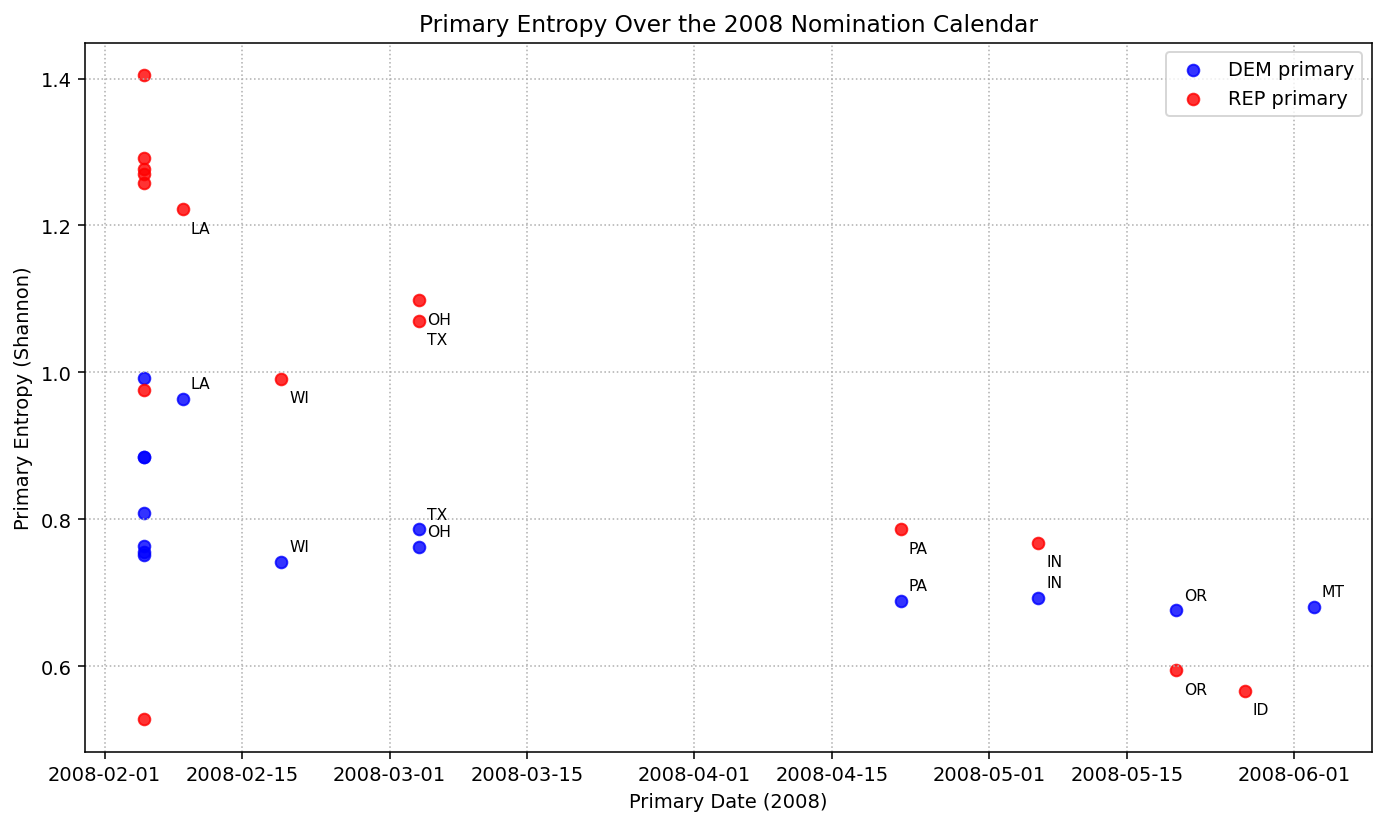

In [10]:
# Plot entropy over time, by party
entropy_long_2008 = entropy_long_2008.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

# Scatter only (no lines)
for party, sub in entropy_long_2008.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

# Only label non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2008-02-05")
mask_label = entropy_long_2008["primary_date"] != super_tuesday

for _, r in entropy_long_2008[mask_label].iterrows():
    if r["party"] == "DEM":
        dx, dy, va = 4, 4, "bottom"
    else:  # REP
        dx, dy, va = 4, -6, "top"

    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va=va,
    )

plt.xlabel("Primary Date (2008)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2008 Nomination Calendar")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

This visualization lets us see, for 2008:

- How scattered the primary entropies are over time.

- Whether the earliest states (often on or near Super Tuesday) tend to have higher or lower entropy than later states.

- Differences between Democratic and Republican patterns.

From the plotted points, we can roughly see that:

- Republican entropy values are generally higher than Democratic ones in many states, indicating more multi-candidate competition in the REP field.

- Some late-voting states (like Montana or Oregon) show relatively lower entropy, suggesting more consolidated support behind a smaller number of candidates by that point in the calendar.

To summarize whether entropy tends to increase or decrease over time, we also fit a simple linear regression of entropy on the numeric date (for each party separately). This yields a straight trend line overlaying the scatter plot.

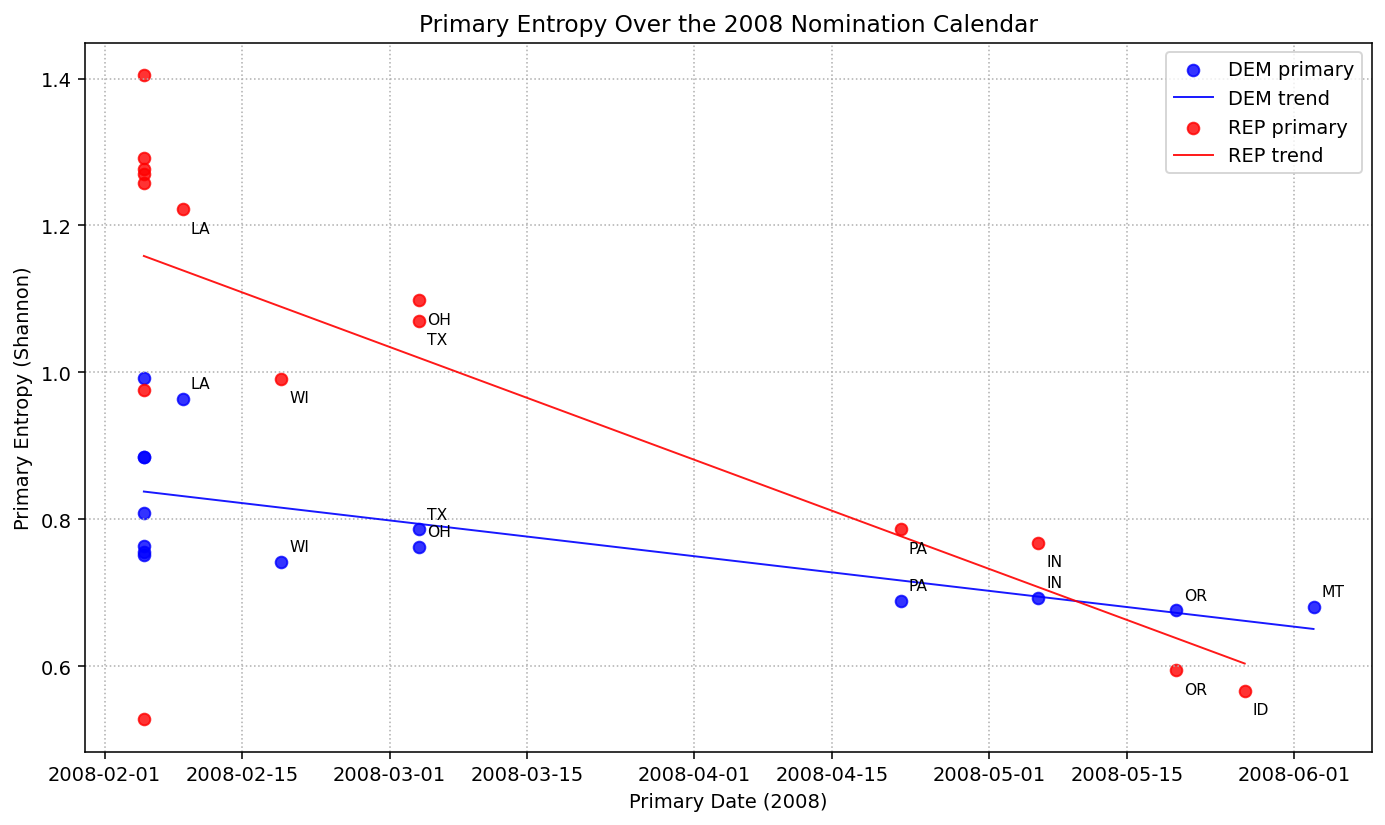

In [11]:
# Or perhaps with trend lines
entropy_long_2008 = entropy_long_2008.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

# Scatter only (no lines)
for party, sub in entropy_long_2008.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

    # Trend line for this party 
    # Convert dates to numeric for regression
    x_num = mdates.date2num(sub["primary_date"])
    y = sub["entropy"].to_numpy()

    # Simple linear fit: entropy = a * date_num + b
    a, b = np.polyfit(x_num, y, 1)

    # Dense grid over this party's date range
    xs_num = np.linspace(x_num.min(), x_num.max(), 200)
    ys = a * xs_num + b

    # Plot trend line (convert back to dates)
    plt.plot(
        mdates.num2date(xs_num),
        ys,
        color=colors[party],
        linestyle="-",
        linewidth=1,
        alpha=0.9,
        label=f"{party} trend",
    )

# Only label non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2008-02-05")
mask_label = entropy_long_2008["primary_date"] != super_tuesday

for _, r in entropy_long_2008[mask_label].iterrows():
    if r["party"] == "DEM":
        dx, dy, va = 4, 4, "bottom"
    else:  # REP
        dx, dy, va = 4, -6, "top"

    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va=va,
    )

plt.xlabel("Primary Date (2008)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2008 Nomination Calendar")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

The trend lines summarize the direction of change:

- If a line slopes down, entropy is decreasing over time (the field is narrowing).

- If it slopes up, the contest is becoming more fragmented.

In 2008, we generally see **entropy decreasing over time**, especially for the Republicans, consistent with a field that starts off competitive and gradually converges on a nominee.

### 2.2. 2016 Presidential Election

#### 2.2.1. Define primary dates and create long table

We repeat the same pattern for 2016. We first inspect which states are present in `primary_entropy_2016`, then hand-code the relevant primary dates for each of them. In 2016, most states have the same primary day for both parties, but some (like South Carolina) differ.

In [34]:
# List of states in 2016 dataframe
primary_entropy_2016["state"].values

array(['AL', 'AR', 'CA', 'FL', 'GA', 'MA', 'MD', 'MS', 'MT', 'NC', 'NM',
       'OH', 'OR', 'PA', 'SC', 'TN', 'VT', 'WA', 'WI'], dtype=object)

Then we define the mapping from (state, party) to date.

Source link: https://www.fec.gov/resources/cms-content/documents/2016pdates.pdf

In [16]:
# Hard-coded the 2016 dates for the all states
primary_dates_2016 = {
    "AL": {  # Alabama – both parties Super Tuesday
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "AR": {  # Arkansas – both parties Super Tuesday
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "CA": {  # California – both parties June 7
        "DEM": "2016-06-07",
        "REP": "2016-06-07",
    },
    "FL": {  # Florida – both parties March 15
        "DEM": "2016-03-15",
        "REP": "2016-03-15",
    },
    "GA": {  # Georgia – both parties March 1
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "MA": {  # Massachusetts – both parties March 1
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "MD": {  # Maryland – both parties April 26
        "DEM": "2016-04-26",
        "REP": "2016-04-26",
    },
    "MS": {  # Mississippi – both parties March 8
        "DEM": "2016-03-08",
        "REP": "2016-03-08",
    },
    "MT": {  # Montana – both parties June 7
        "DEM": "2016-06-07",
        "REP": "2016-06-07",
    },
    "NC": {  # North Carolina – both parties March 15
        "DEM": "2016-03-15",
        "REP": "2016-03-15",
    },
    "NM": {  # New Mexico – both parties June 7
        "DEM": "2016-06-07",
        "REP": "2016-06-07",
    },
    "OH": {  # Ohio – both parties March 15
        "DEM": "2016-03-15",
        "REP": "2016-03-15",
    },
    "OR": {  # Oregon – both parties May 17
        "DEM": "2016-05-17",
        "REP": "2016-05-17",
    },
    "PA": {  # Pennsylvania – both parties April 26
        "DEM": "2016-04-26",
        "REP": "2016-04-26",
    },
    "SC": {  # South Carolina – different dates
        "DEM": "2016-02-27",  # Democratic primary
        "REP": "2016-02-20",  # Republican primary
    },
    "TN": {  # Tennessee – both parties March 1
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "VT": {  # Vermont – both parties March 1
        "DEM": "2016-03-01",
        "REP": "2016-03-01",
    },
    "WA": {  # Washington - both parties May 24
        "DEM": "2016-05-24",  
        "REP": "2016-05-24",  
    },
    "WI": {  # Wisconsin – both parties April 5
        "DEM": "2016-04-05",
        "REP": "2016-04-05",
    },
}

Now we reshape `primary_entropy_2016` into a long format just like we did for 2008.

In [17]:
# Reshape to long format with a date column
records = []

for _, row in primary_entropy_2016.iterrows():
    state = row["state"]
    for party, col in [("DEM", "entropy_dem"), ("REP", "entropy_rep")]:
        entropy = row[col]
        date_str = primary_dates_2016[state][party]
        records.append({
            "state": state,
            "party": party,
            "primary_date": pd.to_datetime(date_str),
            "entropy": entropy,
        })

entropy_long_2016 = pd.DataFrame(records)
entropy_long_2016.head(20)

,state,party,primary_date,entropy
0,AL,DEM,2016-03-01,0.532308
1,AL,REP,2016-03-01,1.453152
2,AR,DEM,2016-03-01,0.817527
3,AR,REP,2016-03-01,1.490531
4,CA,DEM,2016-06-07,0.749048
5,CA,REP,2016-06-07,0.849196
6,FL,DEM,2016-03-15,0.733152
7,FL,REP,2016-03-15,1.350771
8,GA,DEM,2016-03-01,0.629545
9,GA,REP,2016-03-01,1.464878


Again, this produces a tidy dataset where each row corresponds to a single (state, party, date) entropy observation.

#### 2.2.2. Plot 2016 entropy over time

We now visualize the 2016 entropy values in the same way as 2008: a scatter plot with separate colors for Democrats and Republicans, and with state labels for non–Super Tuesday dates.

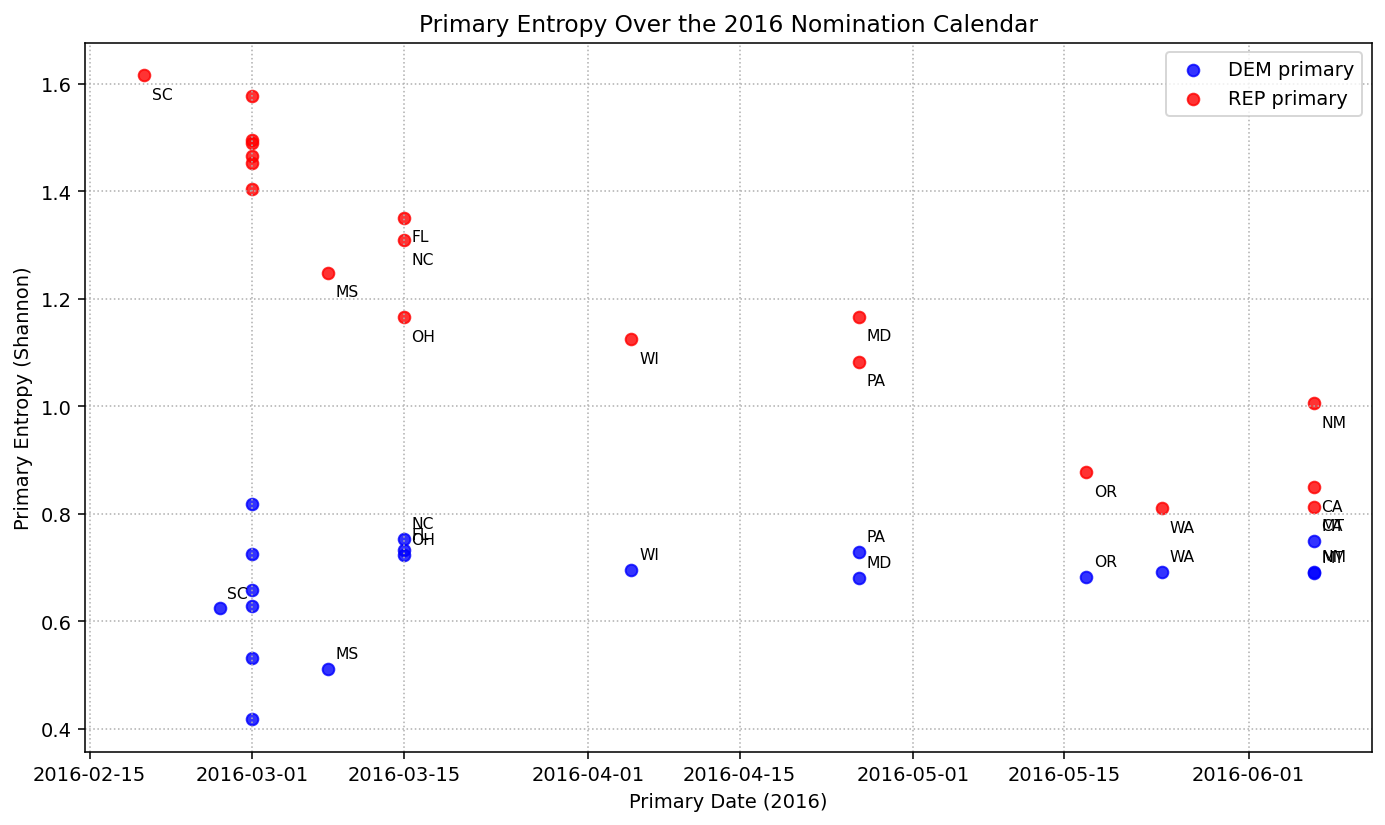

In [18]:
# Plot entropy over time, by party
entropy_long_2016 = entropy_long_2016.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

# Scatter only (no lines)
for party, sub in entropy_long_2016.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

# Only label non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2016-03-01")
mask_label = entropy_long_2016["primary_date"] != super_tuesday

for _, r in entropy_long_2016[mask_label].iterrows():
    if r["party"] == "DEM":
        dx, dy, va = 4, 4, "bottom"
    else:  # REP
        dx, dy, va = 4, -6, "top"

    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va=va,
    )

plt.xlabel("Primary Date (2016)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2016 Nomination Calendar")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

From this scatter, we can see:

- Republican entropy in 2016 is often quite high, especially early and mid-season (e.g., Alabama, Georgia, South Carolina).

- Democratic entropy tends to be lower overall than Republican entropy, consistent with a more concentrated race (dominated by a small number of candidates, mainly Clinton vs. Sanders).

- Later primary dates like California and Montana often show somewhat lower REP entropy than earlier states, again hinting at consolidation over time.

Finally, we overlay trend lines on the 2016 plot, just as we did for 2008, to summarize the direction of change in entropy over time.

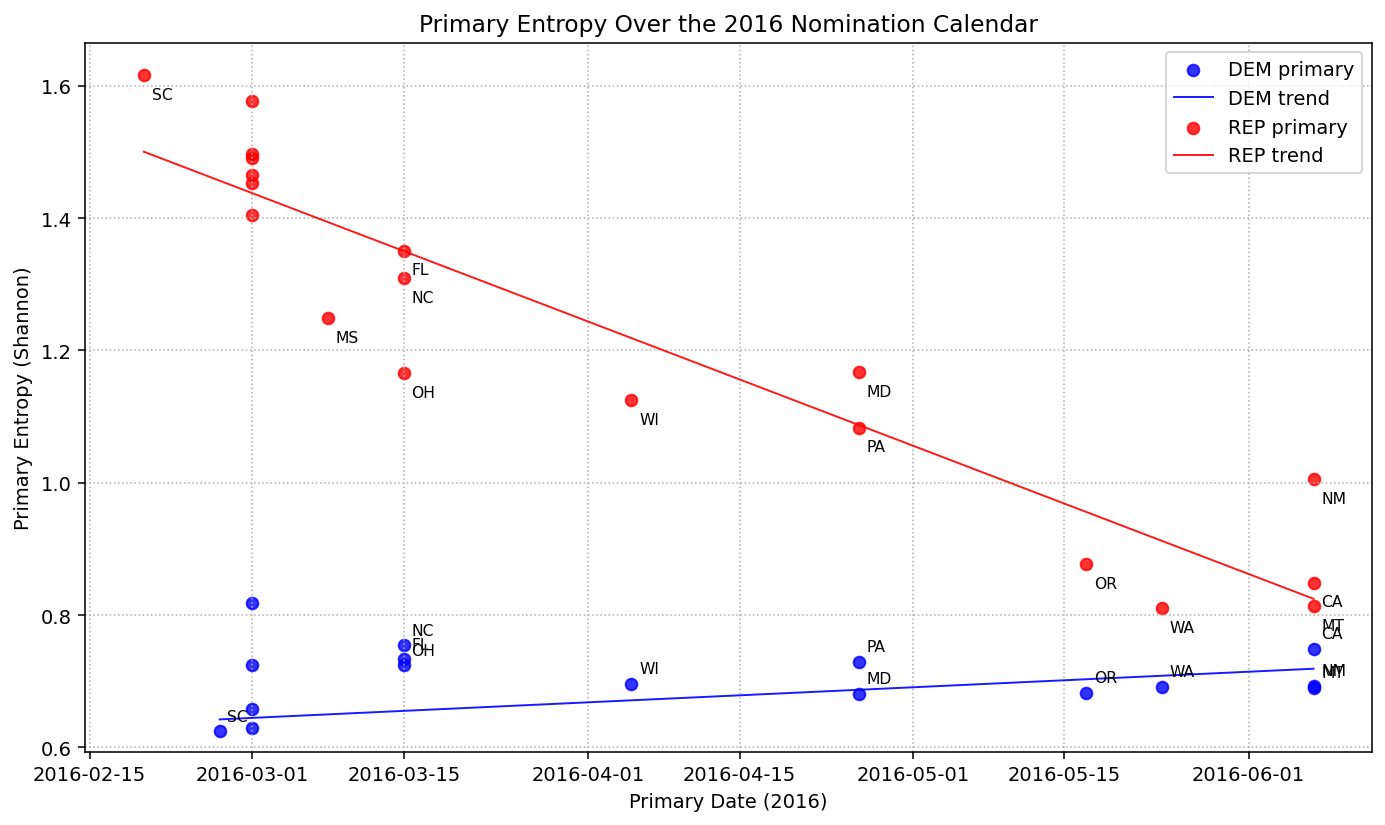

In [19]:
# Or perhaps with trend lines
entropy_long_2016 = entropy_long_2016.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

# Scatter only (no lines)
for party, sub in entropy_long_2016.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

    # Trend line for this party 
    # Convert dates to numeric for regression
    x_num = mdates.date2num(sub["primary_date"])
    y = sub["entropy"].to_numpy()

    # Simple linear fit: entropy = a * date_num + b
    a, b = np.polyfit(x_num, y, 1)

    # Dense grid over this party's date range
    xs_num = np.linspace(x_num.min(), x_num.max(), 200)
    ys = a * xs_num + b

    # Plot trend line (convert back to dates)
    plt.plot(
        mdates.num2date(xs_num),
        ys,
        color=colors[party],
        linestyle="-",
        linewidth=1,
        alpha=0.9,
        label=f"{party} trend",
    )

# Only label non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2016-03-01")
mask_label = entropy_long_2016["primary_date"] != super_tuesday

for _, r in entropy_long_2016[mask_label].iterrows():
    if r["party"] == "DEM":
        dx, dy, va = 4, 4, "bottom"
    else:  # REP
        dx, dy, va = 4, -6, "top"

    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va=va,
    )

plt.xlabel("Primary Date (2016)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2016 Nomination Calendar")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

The trend lines for 2016 show:

- A **noticeable downward slope** for Republican entropy, indicating that the REP primary became less competitive (lower entropy) as we moved toward June. That matches the intuition of a large, fragmented field early on that eventually coalesces behind a frontrunner.

- A lower-range but positive-slope line for Democratic entropy, since the Democratic race is mostly a two-candidate contest and is more consolidated from the beginning.

### 2.3. 2020 Presidential Election

For 2020, we again attach a primary date to each state so we can place the entropy values on the nomination calendar.

Because many 2020 contests were delayed (COVID-era rescheduling), I pulled the **final scheduled primary dates** from the 270toWin 2020 election calendar:

Source: https://www.270towin.com/2020-election-calendar/

Below is a minimal dictionary for just the states we kept in `keep_states_3`. If you expand `keep_states_3` later, you’ll just add more entries here.

In [13]:
# Hard-coded the 2020 dates for the states we kept
primary_dates_2020 = {
    "AL": {
        "DEM": "2020-03-03", 
        "REP": "2020-03-03"
    },
    "AR": {
        "DEM": "2020-03-03", 
        "REP": "2020-03-03"
    },
    "CO": {
        "DEM": "2020-03-03", 
        "REP": "2020-03-03"
    },
    "CT": {
        "DEM": "2020-08-11", 
        "REP": "2020-08-11"
    },  # rescheduled from April 28
    "DE": {
        "DEM": "2020-07-07", 
        "REP": "2020-07-07"
    },  # rescheduled from April 28
    "GA": {
        "DEM": "2020-06-09", 
        "REP": "2020-06-09"
    },  # rescheduled from March 24
    "ID": {
        "DEM": "2020-03-10", 
        "REP": "2020-03-10"
    },
    "IN": {
        "DEM": "2020-06-02", 
        "REP": "2020-06-02"
    },  # rescheduled from May 5
    "MA": {
        "DEM": "2020-03-03", 
        "REP": "2020-03-03"
    },
    "MS": {
        "DEM": "2020-03-10", 
        "REP": "2020-03-10"
    },
    "OR": {
        "DEM": "2020-05-19", 
        "REP": "2020-05-19"
    },
    "WA": {
        "DEM": "2020-03-10", 
        "REP": "2020-03-10"
    },
    "WV": {
        "DEM": "2020-06-09", 
        "REP": "2020-06-09"
    },  # rescheduled from May 12
    "WI": {
        "DEM": "2020-04-07", 
        "REP": "2020-04-07"
    },
}

Next, we reshape `primary_entropy_2020` into the same long format as the earlier years.

Two small “defensive” choices here (to avoid annoying key errors while you’re still expanding the 2020 pipeline):

- If a state is missing from `primary_dates_2020`, we skip it.
- If an entropy value is missing (`NaN`) for a party, we skip that (state, party) point.

In [14]:
# Reshape to long format with a date column
records = []

for _, row in primary_entropy_2020.iterrows():
    state = row["state"]

    # Skip if we don't have a primary date for this state yet
    if state not in primary_dates_2020:
        continue

    for party, col in [("DEM", "entropy_dem"), ("REP", "entropy_rep")]:
        entropy = row[col]
        if pd.isna(entropy):
            continue

        date_str = primary_dates_2020[state][party]
        if date_str is None:
            continue

        records.append({
            "state": state,
            "party": party,
            "primary_date": pd.to_datetime(date_str),
            "entropy": float(entropy),
        })

entropy_long_2020 = pd.DataFrame(records)
entropy_long_2020.head(20)

,state,party,primary_date,entropy
0,AL,DEM,2020-03-03,1.211137
1,AL,REP,2020-03-03,0.242917
2,AR,DEM,2020-03-03,1.455465
3,AR,REP,2020-03-03,0.136318
4,CO,DEM,2020-03-03,1.453597
5,CO,REP,2020-03-03,0.374484
6,CT,DEM,2020-08-11,0.530117
7,CT,REP,2020-08-11,0.661388
8,DE,DEM,2020-07-07,-0.000000
9,DE,REP,2020-07-07,-0.000000


#### 2.3.2. Plot 2020 entropy over time

We now plot entropy vs. date for 2020. To keep the plot readable, we label only the states that are **not** on Super Tuesday (March 3, 2020).

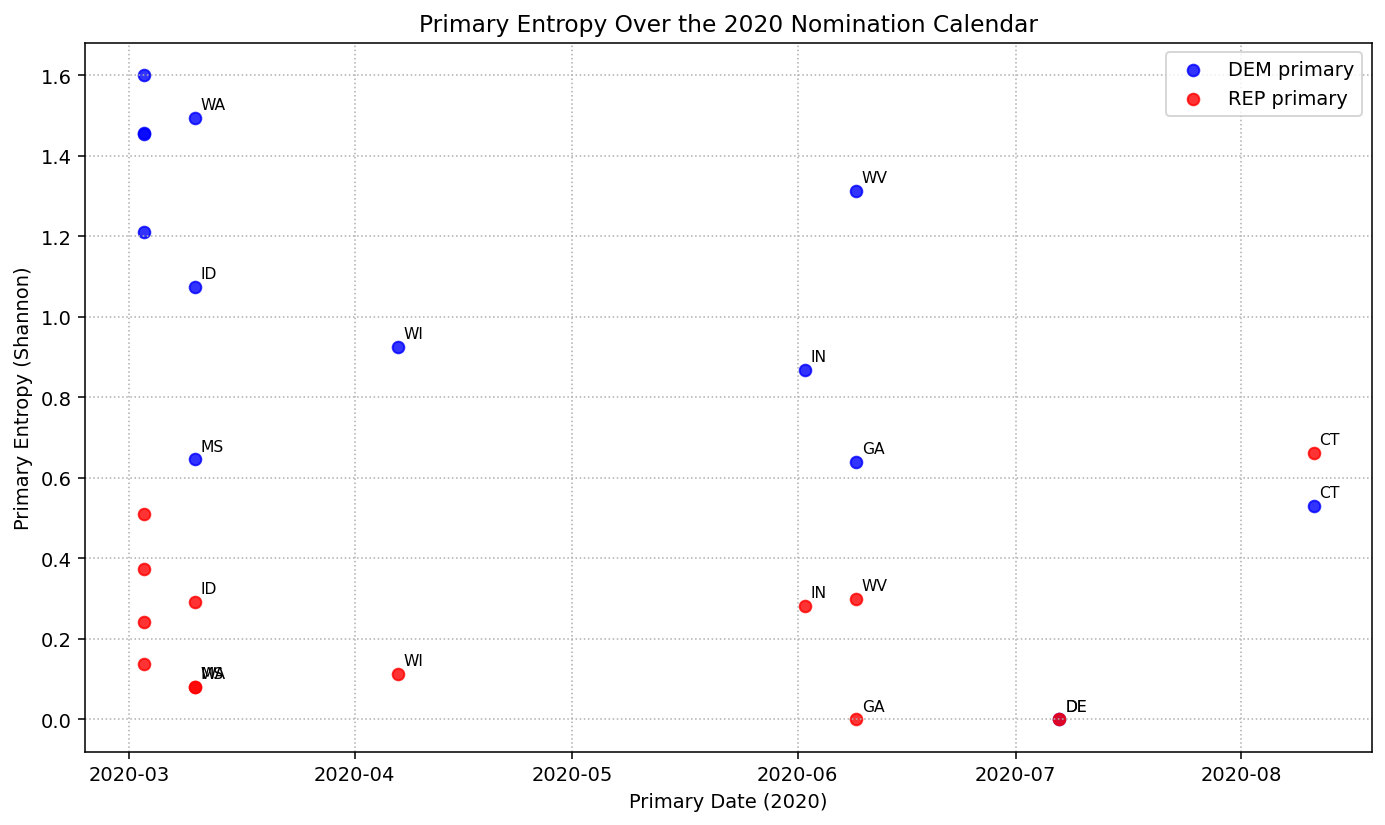

In [15]:
entropy_long_2020 = entropy_long_2020.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

for party, sub in entropy_long_2020.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

# Label only non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2020-03-03")
mask_label = entropy_long_2020["primary_date"] != super_tuesday

for _, r in entropy_long_2020[mask_label].iterrows():
    dx, dy = (3, 3)
    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
    )

plt.xlabel("Primary Date (2020)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2020 Nomination Calendar")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

As with 2016, we can add simple linear trend lines (just to get a directional sense of whether entropy tends to rise or fall over the calendar).

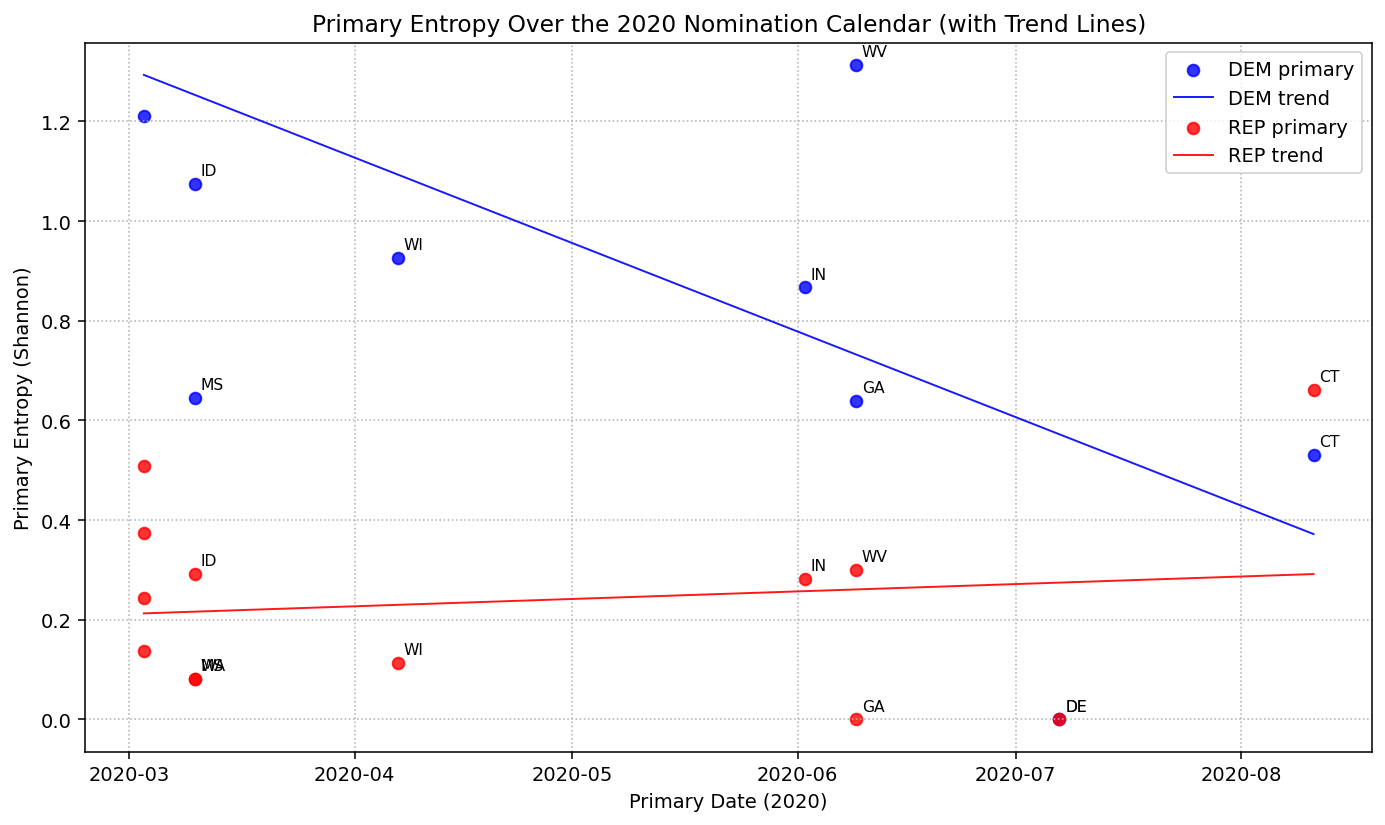

In [16]:
entropy_long_2020 = entropy_long_2020.sort_values("primary_date")

plt.figure(figsize=(10, 6), dpi=140)

colors = {"DEM": "blue", "REP": "red"}

for party, sub in entropy_long_2020.groupby("party"):
    plt.scatter(
        sub["primary_date"],
        sub["entropy"],
        color=colors[party],
        alpha=0.8,
        label=f"{party} primary",
    )

    # Trend line in date-number space
    xs = mdates.date2num(sub["primary_date"])
    ys = sub["entropy"].values
    if len(xs) >= 2:
        coeff = np.polyfit(xs, ys, 1)
        xs_num = np.linspace(xs.min(), xs.max(), 100)
        ys_hat = np.polyval(coeff, xs_num)
        plt.plot(
            mdates.num2date(xs_num),
            ys_hat,
            color=colors[party],
            linestyle="-",
            linewidth=1,
            alpha=0.9,
            label=f"{party} trend",
        )

# Label only non–Super Tuesday states to avoid clutter
super_tuesday = pd.Timestamp("2020-03-03")
mask_label = entropy_long_2020["primary_date"] != super_tuesday

for _, r in entropy_long_2020[mask_label].iterrows():
    plt.annotate(
        r["state"],
        (r["primary_date"], r["entropy"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
    )

plt.xlabel("Primary Date (2020)")
plt.ylabel("Primary Entropy (Shannon)")
plt.title("Primary Entropy Over the 2020 Nomination Calendar (with Trend Lines)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

In 2020, the “time” axis is heavily affected by COVID postponements, so later dates don’t necessarily mean voters waited longer to learn about the field—they often mean the state simply voted later. Still, the pattern is clear.

For Democrats, entropy trends downward over the calendar: early primaries look more competitive (votes spread across multiple candidates → higher entropy), while later primaries look more consolidated (one dominant candidate → lower entropy). For Republicans, entropy stays low across most states, which is what we expect in an incumbent primary: vote shares are concentrated regardless of date, so there’s little time trend.

Overall, 2020 mainly highlights consolidation in the DEM race and stability/low competition in the REP race, with the main caveat that timing is confounded by rescheduling.

## 3. Summary

Throughout the notebook, we found that:

* In 2008 and 2016, Republican primaries often have higher entropy than Democratic primaries in the same states, suggesting GOP vote shares were more spread out across multiple candidates (a more fragmented field), especially early in the season.

* Entropy tends to fall as the calendar moves forward, reflecting the usual “winnowing” effect: candidates drop out, and voters concentrate around fewer viable options.

* In 2016, Democratic entropy is generally lower and steadier, which fits a race that stayed relatively concentrated around a small set of candidates for most of the season.

* Late-season states often show lower entropy than early states, consistent with the idea that many minor candidates are no longer in the race by the time those contests happen.

* In 2020, the interpretation needs one extra caveat: COVID postponements shifted many primary dates, so “late” sometimes means “rescheduled,” not necessarily “late in the decision process.” Even so, the pattern is still informative—Democratic entropy drops as the field consolidates, while Republican entropy stays low overall, which is consistent with an incumbent primary.

Overall, this notebook uses Shannon entropy as a simple, information-theoretic way to quantify how competitive or fragmented a primary is, and to visualize how that competitiveness evolves across the nomination calendar.
